In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.over_sampling import SMOTE
from PIL import Image,ImageOps
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import os

In [3]:
df = pd.read_csv(r"C:\Users\Asus\Downloads\data final\vindr-mammo-a-large-scale-benchmark-dataset-for-computer-aided-detection-and-diagnosis-in-full-field-digital-mammography-1.0.0-jpg\breast-level_annotations.csv")

df.head()


,study_id,series_id,image_id,laterality,view_position,height,width,breast_birads,breast_density,split
0,b8d273e8601f348d3664778dae0e7e0b,b36517b9cbbcfd286a7ae04f643af97a,d8125545210c08e1b1793a5af6458ee2,L,CC,3518,2800,BI-RADS 2,DENSITY C,training
1,b8d273e8601f348d3664778dae0e7e0b,b36517b9cbbcfd286a7ae04f643af97a,290c658f4e75a3f83ec78a847414297c,L,MLO,3518,2800,BI-RADS 2,DENSITY C,training
2,b8d273e8601f348d3664778dae0e7e0b,b36517b9cbbcfd286a7ae04f643af97a,cd0fc7bc53ac632a11643ac4cc91002a,R,CC,3518,2800,BI-RADS 2,DENSITY C,training
3,b8d273e8601f348d3664778dae0e7e0b,b36517b9cbbcfd286a7ae04f643af97a,71638b1e853799f227492bfb08a01491,R,MLO,3518,2800,BI-RADS 2,DENSITY C,training
4,8269f5971eaca3e5d3772d1796e6bd7a,d931832a0815df082c085b6e09d20aac,dd9ce3288c0773e006a294188aadba8e,L,CC,3518,2800,BI-RADS 1,DENSITY C,training


In [5]:
df['birads_numeric'] = df['breast_birads'].str.extract(r'(\d+)').astype(int)

df['class'] = df['birads_numeric'].apply(lambda x: 0 if x == 1 else 1)

df['class'].value_counts()

class
0    13406
1     6594
Name: count, dtype: int64

In [7]:
from sklearn.utils import shuffle
train_df = df[df['split'] == 'training'].sample(frac=0.7, random_state=50).reset_index(drop=True)
test_df = df[df['split'] == 'test'].sample(frac=0.7, random_state=50).reset_index(drop=True)
print(f"Training set size: {len(train_df)}")
print(f"Test set size: {len(test_df)}")


Training set size: 11200
Test set size: 2800


In [9]:
import os
from PIL import Image, ImageOps
import numpy as np

BASE_DIR = r"C:\Users\Asus\Downloads\data final\vindr-mammo-a-large-scale-benchmark-dataset-for-computer-aided-detection-and-diagnosis-in-full-field-digital-mammography-1.0.0-jpg\images3"

def load_image(image_path):
    try:
        img = Image.open(image_path).convert('L')
        img = img.resize((256, 256))
        img = ImageOps.equalize(img)

        return np.array(img, dtype=np.float16) / 255.0
    except Exception as e:
        print(f"Ошибка при загрузке {image_path}: {e}")
        return None


In [11]:
X_train, y_train = [], []

for _, row in train_df.iterrows():
    image_path = os.path.join(BASE_DIR, row['study_id'], f"{row['image_id']}.jpg")
    img = load_image(image_path)
    if img is not None:
        X_train.append(img)
        y_train.append(row['class'])


X_test, y_test = [], []

for _, row in test_df.iterrows():
    image_path = os.path.join(BASE_DIR, row['study_id'], f"{row['image_id']}.jpg")
    img = load_image(image_path)
    if img is not None:
        X_test.append(img)
        y_test.append(row['class'])


X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)




In [12]:
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

In [13]:
pca = PCA(n_components=100, random_state=42)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

In [14]:
from collections import Counter
print("Before SMOTE:", Counter(y_train))

Before SMOTE: Counter({0: 7566, 1: 3634})


In [15]:
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)
print("After SMOTE:", Counter(y_train))

After SMOTE: Counter({0: 7566, 1: 7566})


In [16]:
def evaluate_model(model, X_train, X_test, y_train, y_test, threshold=0.2):
    model.fit(X_train, y_train)  
    y_probs = model.predict_proba(X_test)[:, 1]  
    y_pred = (y_probs > threshold).astype(int)  
    y_pred = model.predict(X_test)
    
   
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)
    
  
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    
   
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.show()

Logistic Regression:
Accuracy: 51.46%
Precision: 56.05%
Recall: 51.46%
F1-Score: 52.91%
ROC-AUC: 50.56%


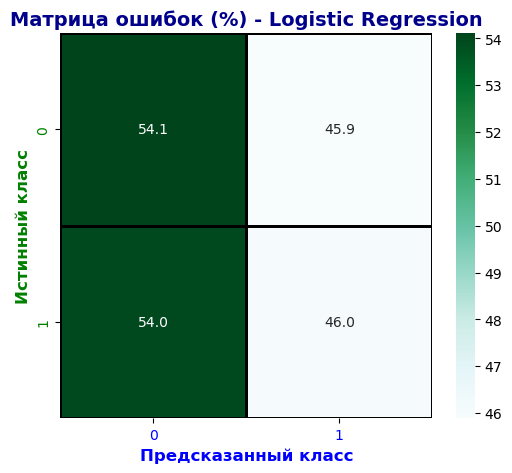

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Logistic Regression:")

# Обучение модели
lr = LogisticRegression(penalty='l1', solver='saga', C=50)
lr.fit(X_train, y_train)

# Предсказания
y_pred = lr.predict(X_test)

# Вычисление метрик в процентах
accuracy = accuracy_score(y_test, y_pred) * 100
precision = precision_score(y_test, y_pred, average='weighted') * 100
recall = recall_score(y_test, y_pred, average='weighted') * 100
f1 = f1_score(y_test, y_pred, average='weighted') * 100
roc_auc = roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1]) * 100

# Вывод результатов в процентах
print(f"Accuracy: {accuracy:.2f}%")
print(f"Precision: {precision:.2f}%")
print(f"Recall: {recall:.2f}%")
print(f"F1-Score: {f1:.2f}%")
print(f"ROC-AUC: {roc_auc:.2f}%")

# Создание Confusion Matrix в процентах
cm = confusion_matrix(y_test, y_pred)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100  # Преобразование в проценты

# Выбор цветовой палитры (яркие синие и зеленые)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap="BuGn", cbar=True, linewidths=1, linecolor='black')

# Улучшения дизайна
plt.xlabel("Предсказанный класс", fontsize=12, fontweight='bold', color="blue")
plt.ylabel("Истинный класс", fontsize=12, fontweight='bold', color="green")
plt.title("Матрица ошибок (%) - Logistic Regression", fontsize=14, fontweight='bold', color="darkblue")
plt.xticks(fontsize=10, color="blue")
plt.yticks(fontsize=10, color="green")

plt.show()


In [25]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10],  
    'penalty': ['l1', 'l2'],  
    'solver': ['liblinear', 'saga'],  
    'max_iter': [100, 500, 1000]  
}

lr = LogisticRegression()

grid_search = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    scoring='recall',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# Вывод лучших параметров
print(f"Best Parameters: {grid_search.best_params_}")

# Recall в процентном виде
best_recall = grid_search.best_score_ * 100
print(f"Best Recall: {best_recall:.2f}%")


Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best Parameters: {'C': 0.01, 'max_iter': 100, 'penalty': 'l1', 'solver': 'liblinear'}
Best Recall: 55.92%


Support Vector Machine:
Accuracy: 52.50%
Precision: 56.45%
Recall: 52.50%
F1-Score: 53.83%
ROC-AUC: 50.54%


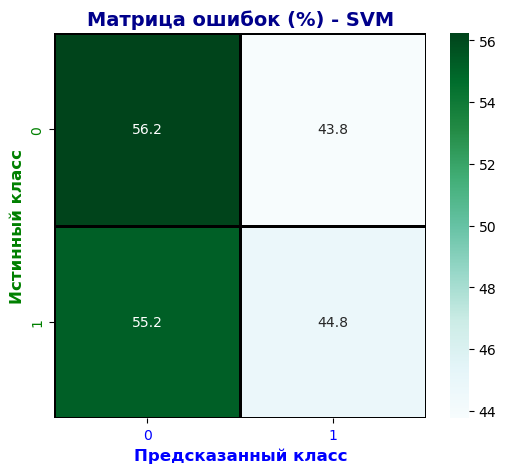

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Support Vector Machine:")

# Обучение модели
svm = SVC(probability=True)
svm.fit(X_train, y_train)

# Предсказания
y_pred = svm.predict(X_test)

# Вычисление метрик в процентах
accuracy = accuracy_score(y_test, y_pred) * 100
precision = precision_score(y_test, y_pred, average='weighted') * 100
recall = recall_score(y_test, y_pred, average='weighted') * 100
f1 = f1_score(y_test, y_pred, average='weighted') * 100
roc_auc = roc_auc_score(y_test, svm.predict_proba(X_test)[:, 1]) * 100

# Вывод результатов в процентах
print(f"Accuracy: {accuracy:.2f}%")
print(f"Precision: {precision:.2f}%")
print(f"Recall: {recall:.2f}%")
print(f"F1-Score: {f1:.2f}%")
print(f"ROC-AUC: {roc_auc:.2f}%")

# Создание Confusion Matrix в процентах
cm = confusion_matrix(y_test, y_pred)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100  # Преобразование в проценты

# Выбор цветовой палитры (яркие синие и зелёные)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap="BuGn", cbar=True, linewidths=1, linecolor='black')

# Улучшения дизайна
plt.xlabel("Предсказанный класс", fontsize=12, fontweight='bold', color="blue")
plt.ylabel("Истинный класс", fontsize=12, fontweight='bold', color="green")
plt.title("Матрица ошибок (%) - SVM", fontsize=14, fontweight='bold', color="darkblue")
plt.xticks(fontsize=10, color="blue")
plt.yticks(fontsize=10, color="green")

plt.show()


In [29]:
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Recall: {grid_search.best_score_:.2%}")  # Процентный формат


Best Parameters: {'C': 0.01, 'max_iter': 100, 'penalty': 'l1', 'solver': 'liblinear'}
Best Recall: 55.92%


Decision Tree:
Accuracy: 33.20%
Precision: 33.31%
Recall: 33.20%
F1-Score: 33.22%
ROC-AUC: 49.92%


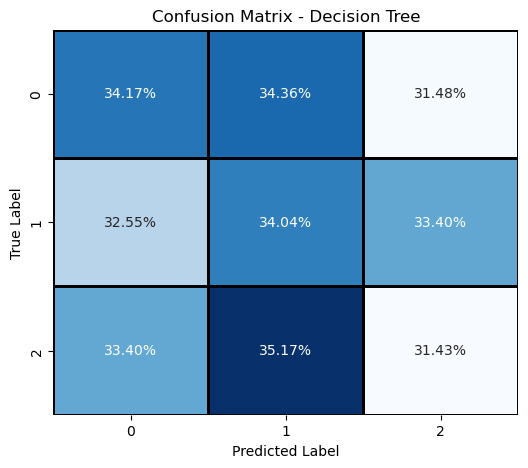

In [47]:
print("Decision Tree:")
dt = DecisionTreeClassifier()
evaluate_model(dt, X_train, X_test, y_train, y_test)

In [51]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import make_scorer, recall_score

# Балансируем классы
smote = SMOTE()
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Определяем поиск лучших гиперпараметров
param_grid = {
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'criterion': ['gini', 'entropy'],
    'max_features': ['sqrt', 'log2']
}

dt = DecisionTreeClassifier(random_state=42)

# Явно указываем, что это многоклассовый Recall
scorer = make_scorer(recall_score, average='macro')

grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring=scorer,
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Обучаем GridSearch на сбалансированных данных
grid_search.fit(X_train_resampled, y_train_resampled)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Recall: {grid_search.best_score_:.2%}")


Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Parameters: {'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Recall: 35.14%


Random Forest:
Accuracy: 33.33%
Precision: 33.41%
Recall: 33.33%
F1-Score: 33.30%
ROC-AUC: 50.80%


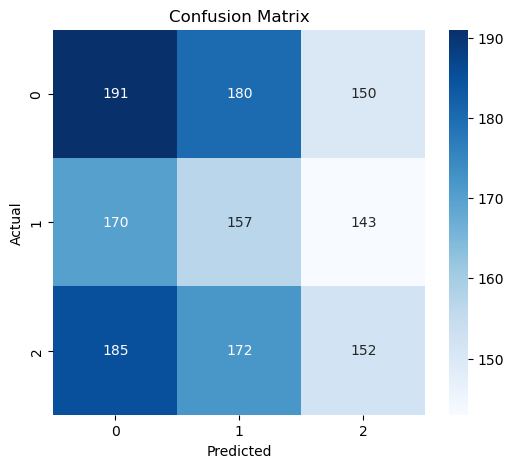

In [67]:
print("Random Forest:")
rf = RandomForestClassifier()
evaluate_model(rf, X_train, X_test, y_train, y_test)

In [77]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [50, 100, 200],     
    'max_depth': [None, 10, 20],   
    'min_samples_split': [2, 5],    
    'min_samples_leaf': [1, 2],     
    'criterion': ['gini', 'entropy'],   
    'max_features': ['sqrt', 'log2']  
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,              
    param_grid=param_grid,     
    scoring='recall_weighted',  # Используем weighted для многоклассовой задачи
    cv=5,                      
    n_jobs=-1,                 
    verbose=1                  
)

grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Recall: {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best Recall: 0.3360


Fitting 5 folds for each of 72 candidates, totalling 360 fits
Лучшие параметры: {'knn__metric': 'manhattan', 'knn__n_neighbors': 9, 'knn__weights': 'distance'}
Лучший Recall на кросс-валидации: 35.56%
Метрики модели:
Recall: 33.73%
Accuracy: 33.73%
Precision: 33.70%
F1-score: 33.70%
ROC AUC: 50.03%


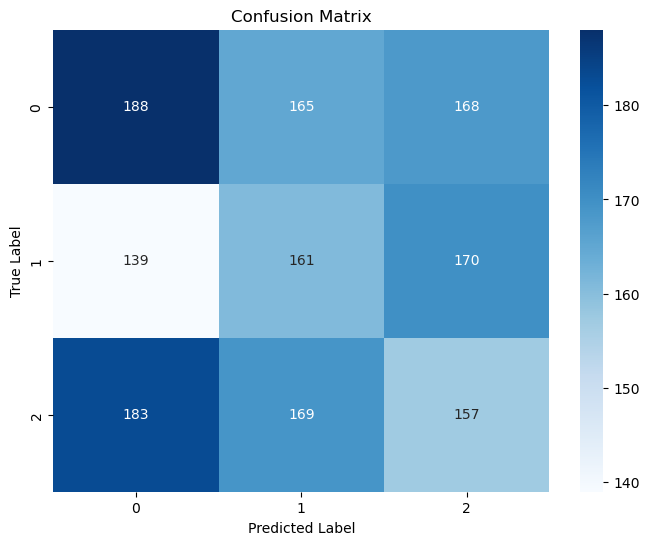

In [117]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler
from sklearn.decomposition import PCA
from sklearn.metrics import recall_score, accuracy_score, precision_score, f1_score, roc_auc_score

def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)
    
    recall = recall_score(y_test, y_pred, average='macro')
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro')
    roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='macro')
    
    print("Метрики модели:")
    print(f"Recall: {recall:.2%}")
    print(f"Accuracy: {accuracy:.2%}")
    print(f"Precision: {precision:.2%}")
    print(f"F1-score: {f1:.2%}")
    print(f"ROC AUC: {roc_auc:.2%}")
    
    # Построение confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=set(y_test), yticklabels=set(y_test))
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

# Балансировка классов
oversampler = RandomOverSampler()
# Масштабирование данных
scaler = StandardScaler()
# PCA для уменьшения размерности (оставим 95% информации)
pca = PCA(n_components=0.95)
# KNN модель
knn = KNeighborsClassifier()

# Pipeline
knn_pipeline = Pipeline([
    ('oversampler', oversampler),
    ('scaler', scaler),
    ('pca', pca),
    ('knn', knn)
])

# Гиперпараметры для подбора
param_grid = {
    'knn__n_neighbors': [1, 3, 5, 7, 9, 11, 15, 21, 31],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan', 'minkowski', 'chebyshev']
}

# StratifiedKFold для лучшего разделения классов
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearchCV
grid_search = GridSearchCV(knn_pipeline, param_grid, scoring='recall_macro', cv=cv, n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

# Выводим лучшие параметры
print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучший Recall на кросс-валидации: {grid_search.best_score_:.2%}")

# Оцениваем лучшую модель
best_knn = grid_search.best_estimator_
evaluate_model(best_knn, X_train, X_test, y_train, y_test)